# Visual-Language Navigation for Legged Robots using RGB Images
## CS 691 Course Project 

In [1]:
import random, json, functools
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
 
EMBODIMENT = "Legged Robot"
CKPT       = "./best_mlp_simple.pt"
EMBED_VAL  = "./val_embeddings_simple.pt"
VAL_SPLIT  = 0.2
SEED       = 42
N_SHOW     = 6
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

goal_mean = torch.tensor([0.4935, 0.4728], dtype=torch.float32)
goal_std  = torch.tensor([0.2151, 0.1108], dtype=torch.float32)
 
print("Loading NaviTrace validation split...")
dataset = load_dataset("leggedrobotics/navitrace")

val_split_samples = []
for s in tqdm(list(dataset["validation"]), desc="Filtering"):
    gt = s["ground_truth"].get(EMBODIMENT)
    if gt is not None and len(gt) > 0:
        val_split_samples.append(s)
print(f"Loaded {len(val_split_samples)} samples")
 
random.seed(SEED)
random.shuffle(val_split_samples)
n_val       = int(len(val_split_samples) * VAL_SPLIT)
val_samples = val_split_samples[:n_val]
print(f"Val samples : {len(val_samples)}")
 
trace_lengths = [
    len(t) for s in val_samples
    for t in s["ground_truth"][EMBODIMENT]
]
N = int(np.median(trace_lengths))
print(f"N waypoints : {N}")
 
print("Loading val embeddings...")
val_emb   = torch.load(EMBED_VAL, weights_only=False)
val_joint = torch.cat([val_emb["img_emb"], val_emb["txt_emb"]], dim=-1)
print(f"Val joint : {val_joint.shape}")
 
class NavigationMLP(nn.Module):
    def __init__(self, N):
        super().__init__()
        self.N = N
        self.shared = nn.Sequential(
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.15)
        )
        self.goal_head = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 2)
        )
        self.trace_head = nn.Sequential(
            nn.Linear(258, 128), nn.ReLU(),
            nn.Dropout(0.15), nn.Linear(128, N * 2), nn.Sigmoid()
        )

    def forward(self, x):
        h = self.shared(x)
        g = self.goal_head(h)
        t = self.trace_head(torch.cat([h, g.detach()], dim=-1))
        return g, t.view(-1, self.N, 2)

model = NavigationMLP(N).to(DEVICE)
model.load_state_dict(torch.load(CKPT, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from {CKPT}")

/home/arif/miniconda3/envs/vln/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading NaviTrace validation split...


Filtering: 100%|██████████████████████████| 502/502 [00:00<00:00, 980689.62it/s]

Loaded 501 samples
Val samples : 100
N waypoints : 9
Loading val embeddings...
Val joint : torch.Size([100, 1024])
Model loaded from ./best_mlp_simple.pt


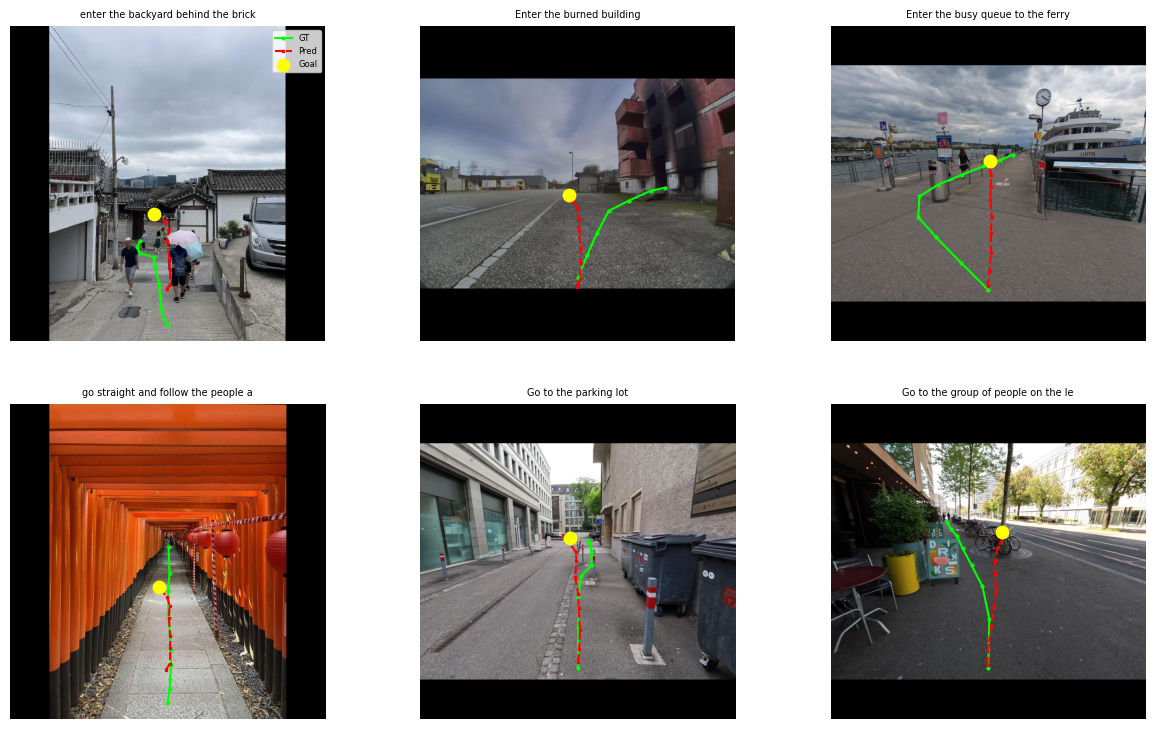

In [6]:
with torch.no_grad():
    goal_raw, trace_norm = model(val_joint.to(DEVICE))
    goal_raw   = goal_raw.cpu().numpy()
    trace_norm = trace_norm.cpu().numpy()

gm = goal_mean.numpy()
gs = goal_std.numpy()
goal_preds = np.clip(goal_raw * gs + gm, 0, 1)
 
def to_pixel(pred_norm, orig_w, orig_h):
    max_s  = max(orig_w, orig_h)
    x_off  = (max_s - orig_w) / 2
    y_off  = (max_s - orig_h) / 2
    p      = pred_norm.copy()
    p[:,0] = np.clip(p[:,0] * max_s - x_off, 0, orig_w - 1)
    p[:,1] = np.clip(p[:,1] * max_s - y_off, 0, orig_h - 1)
    return p

 
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, ax in enumerate(axes.flatten()):
    sample         = val_samples[i]
    img            = sample["image"].convert("RGB")
    orig_w, orig_h = img.size
    max_s          = max(orig_w, orig_h)
    x_off          = (max_s - orig_w) // 2
    y_off          = (max_s - orig_h) // 2

    canvas = np.zeros((max_s, max_s, 3), dtype=np.uint8)
    canvas[y_off:y_off+orig_h, x_off:x_off+orig_w] = np.array(img)
    ax.imshow(canvas)

    # GT traces
    for j, gt in enumerate(sample["ground_truth"][EMBODIMENT]):
        gt = np.array(gt)
        ax.plot(gt[:,0] + x_off, gt[:,1] + y_off,
                "o-", color="lime", lw=1.5, ms=2,
                label="GT" if j == 0 else None)

    # Predicted trace
    p = to_pixel(trace_norm[i], orig_w, orig_h)
    ax.plot(p[:,0] + x_off, p[:,1] + y_off,
            "s--", color="red", lw=1.5, ms=2, label="Pred")

    # Predicted goal
    gx = np.clip(goal_preds[i][0] * max_s - (max_s - orig_w) / 2, 0, orig_w - 1)
    gy = np.clip(goal_preds[i][1] * max_s - (max_s - orig_h) / 2, 0, orig_h - 1)
    ax.scatter(gx + x_off, gy + y_off, s=80, c="yellow", zorder=6, label="Goal")

    ax.set_title(sample["task"][:35], fontsize=7)
    ax.axis("off")
    if i == 0:
        ax.legend(fontsize=6, loc="upper right")

In [9]:
import pandas as pd
from scipy.spatial import KDTree
from skimage.draw import line_aa
from skimage.draw import line as sk_line

PENALTY_TSV = "./category_penalty.tsv"
M2F_CONFIG  = "./mask2former_config.json"
BAD_SCORE   = 3234.75
DTHR        = 35

@functools.lru_cache(maxsize=4)
def penalty_lookup(embodiment):
    df  = pd.read_csv(PENALTY_TSV, sep="\t")
    with open(M2F_CONFIG) as f:
        m2f = json.load(f)
    id2label = {int(k): v for k, v in m2f["id2label"].items()}
    lkp = {}
    for lid, name in id2label.items():
        row = df[df["category"] == name]
        lkp[lid] = float(row.iloc[0][embodiment]) * 0.8 if len(row) else 0.0
    return lkp

def rasterize(trace, H, W):
    pts, pixels = np.array(trace), []
    if len(pts) > 1:
        for i in range(len(pts)-1):
            r0,c0 = int(round(pts[i][1])),   int(round(pts[i][0]))
            r1,c1 = int(round(pts[i+1][1])), int(round(pts[i+1][0]))
            rr,cc,_ = line_aa(r0,c0,r1,c1)
            v = (rr>=0)&(rr<H)&(cc>=0)&(cc<W)
            pixels.extend(zip(rr[v],cc[v]))
    elif len(pts)==1:
        r,c = int(round(pts[0][1])), int(round(pts[0][0]))
        if 0<=r<H and 0<=c<W: pixels.append((r,c))
    return np.array(pixels)

def penalty_mask(seg, gt_px, emb):
    H,W  = seg.shape
    mask = np.zeros((H,W), dtype=float)
    lkp  = penalty_lookup(emb)
    gtp  = rasterize(gt_px, H, W)
    if len(gtp)==0: return mask
    tree = KDTree(gtp)
    ids  = seg.ravel()
    und  = np.where(np.isin(ids, list(lkp.keys())))[0]
    if und.size==0: return mask
    rows,cols  = np.unravel_index(und,(H,W))
    coords     = np.vstack((rows,cols)).T
    dist,_     = tree.query(coords)
    pen_idx    = coords[dist>DTHR]
    if pen_idx.size>0:
        rp,cp = pen_idx[:,0], pen_idx[:,1]
        mask[rp,cp] = np.vectorize(lkp.get)(seg[rp,cp], 0)
    return mask

def sem_penalty(pred_px, pmask):
    H,W  = pmask.shape
    vals = []
    for i in range(len(pred_px)-1):
        x1,y1 = int(round(pred_px[i][0])),   int(round(pred_px[i][1]))
        x2,y2 = int(round(pred_px[i+1][0])), int(round(pred_px[i+1][1]))
        rr,cc  = sk_line(y1,x1,y2,x2)
        v      = (rr>=0)&(rr<H)&(cc>=0)&(cc<W)
        vals.extend(pmask[rr[v],cc[v]].tolist())
    return float(np.mean(vals)) if vals else 0.0

def calc_fde(p,g):
    return float(np.linalg.norm(np.array(p[-1])-np.array(g[-1])))

def calc_dtw(p,g):
    p=np.array(p,dtype=float); g=np.array(g,dtype=float)
    if len(p)!=len(g):
        longer,shorter=(p,g) if len(p)>=len(g) else (g,p)
        d=np.cumsum([0]+[np.linalg.norm(shorter[i]-shorter[i-1])
                         for i in range(1,len(shorter))])
        tot=d[-1]
        if tot>0: d=d/tot
        t=np.linspace(0,1,len(longer))
        shorter=np.column_stack([np.interp(t,d,shorter[:,0]),
                                  np.interp(t,d,shorter[:,1])])
        p,g=(longer,shorter) if len(p)>=len(g) else (shorter,longer)
    n,m=len(p),len(g); D=np.full((n+1,m+1),np.inf); D[0,0]=0
    for i in range(1,n+1):
        for j in range(1,m+1):
            D[i,j]=np.linalg.norm(p[i-1]-g[j-1])+min(D[i-1,j],D[i,j-1],D[i-1,j-1])
    return float(D[n,m])

# Score all val samples
nt_scores = []
skipped   = 0

for i in tqdm(range(len(val_samples)), desc="Scoring"):
    sample    = val_samples[i]
    gt_traces = sample["ground_truth"].get(EMBODIMENT)
    if not gt_traces:
        skipped += 1; continue

    img            = sample["image"]
    orig_w, orig_h = img.size
    seg            = np.array(sample["segmentation_mask"])
    pred_px        = to_pixel(trace_norm[i], orig_w, orig_h).tolist()

    best_raw = float("inf")
    for gt_px in gt_traces:
        pmask = penalty_mask(seg, gt_px, EMBODIMENT)
        raw   = calc_dtw(pred_px, gt_px) + calc_fde(pred_px, gt_px) + sem_penalty(pred_px, pmask)
        if raw < best_raw:
            best_raw = raw

    nt_scores.append((BAD_SCORE - best_raw) / BAD_SCORE * 100)


print(f"  Mean  : {np.mean(nt_scores):.2f}")
print(f"  Std   : {np.std(nt_scores):.2f}")
print(f"  Median: {np.median(nt_scores):.2f}")


Scoring: 100%|████████████████████████████████| 100/100 [07:12<00:00,  4.33s/it]

  Mean  : 26.03
  Std   : 51.15
  Median: 41.68


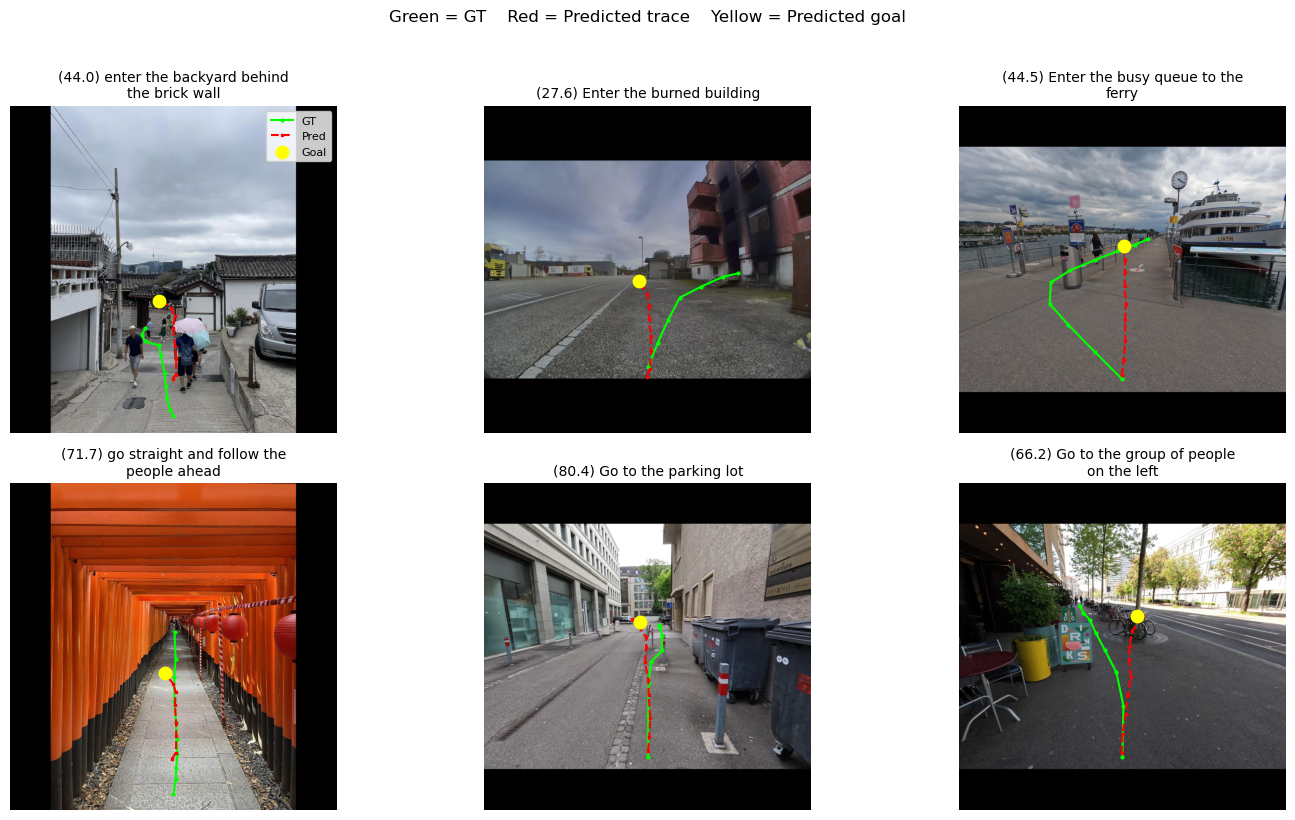

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()


for i, ax in enumerate(axes.flatten()):
    sample         = val_samples[i]
    img            = sample["image"].convert("RGB")
    orig_w, orig_h = img.size
    max_s          = max(orig_w, orig_h)
    x_off          = (max_s - orig_w) // 2
    y_off          = (max_s - orig_h) // 2

    canvas = np.zeros((max_s, max_s, 3), dtype=np.uint8)
    canvas[y_off:y_off+orig_h, x_off:x_off+orig_w] = np.array(img)
    ax.imshow(canvas)

    # GT traces
    for j, gt in enumerate(sample["ground_truth"][EMBODIMENT]):
        gt = np.array(gt)
        ax.plot(gt[:,0] + x_off, gt[:,1] + y_off,
                "o-", color="lime", lw=1.5, ms=2,
                label="GT" if j == 0 else None)

    # Predicted trace
    p = to_pixel(trace_norm[i], orig_w, orig_h)
    ax.plot(p[:,0] + x_off, p[:,1] + y_off,
            "s--", color="red", lw=1.5, ms=2, label="Pred")

    # Predicted goal
    gx = np.clip(goal_preds[i][0] * max_s - (max_s - orig_w) / 2, 0, orig_w - 1)
    gy = np.clip(goal_preds[i][1] * max_s - (max_s - orig_h) / 2, 0, orig_h - 1)
    ax.scatter(gx + x_off, gy + y_off, s=80, c="yellow", zorder=6, label="Goal")

    # Title: split task text into two lines at ~25 chars
    task  = sample["task"]
    if len(task) > 25:
        split = task.rfind(" ", 0, 28)
        split = split if split > 0 else 25
        title = task[:split] + "\n" + task[split:].strip()
    else:
        title = task
    ax.set_title(f"({nt_scores[i]:.1f}) "+title, fontsize=10, pad=6)
    ax.axis("off")
    if i == 0:
        ax.legend(fontsize=8, loc="upper right")

plt.suptitle(
    f"Green = GT    Red = Predicted trace    Yellow = Predicted goal",
    # f"\nCLIP baseline score = {np.mean(nt_scores):.1f} (val split)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig("./qual_predictions_2.png", dpi=150, bbox_inches="tight")
plt.show()